# 01 – Data Exploration & Cleaning

**Goal of the project:** predict the monthly base rent (*Kaltmiete*, column `baseRent`) of a German apartment from its features.

**Data:** Kaggle – *Apartment rental offers in Germany* (ImmoScout24 listings scraped in Sep 2018, May 2019, Oct 2019 and Feb 2020).

**In this notebook**
1. Load the data and get a first overview (shape, columns, missing values, statistics)
2. Look at how the listings are spread across the 16 Bundesländer
3. Clean the data (Phase 2) – every rule is explained
4. Three charts with the key insights

The cleaning logic lives in `src/cleaning.py`, so the modeling notebook, the training script and the app all use *exactly* the same rules.

In [1]:
import sys
sys.path.append("../src")   # lets us import our own module src/cleaning.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import cleaning

pd.set_option("display.max_columns", 50)

# Chart style: one calm blue for data, orange only to highlight, light grey grid
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True,
    "axes.edgecolor": "#8a8983", "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 1. Load the data
Each **row** is one apartment listing, each **column** is one piece of information (a *feature*) about it.

In [2]:
raw = cleaning.load_raw("../data/immo_data.csv")
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

268,850 rows x 49 columns


,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,scoutId,noParkSpaces,firingTypes,hasKitchen,geo_bln,cellar,yearConstructedRange,baseRent,houseNumber,livingSpace,geo_krs,condition,interiorQual,petsAllowed,street,streetPlain,lift,baseRentRange,typeOfFlat,geo_plz,noRooms,thermalChar,floor,numberOfFloors,noRoomsRange,garden,livingSpaceRange,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
0,Nordrhein_Westfalen,245.0,central_heating,ONE_YEAR_FREE,NaN,False,False,6,4.62,10.0,840.0,1965.0,96107057,1.0,oil,False,Nordrhein_Westfalen,True,2.0,595.0,244,86.0,Dortmund,well_kept,normal,NaN,Sch&uuml;ruferstra&szlig;e,Schüruferstraße,False,4,ground_floor,44269,4.0,181.4,1.0,3.0,4,True,4,Dortmund,Schüren,Die ebenerdig zu erreichende Erdgeschosswohnun...,Die Wohnung ist mit Laminat ausgelegt. Das Bad...,NaN,NaN,NaN,NaN,NaN,May19
1,Rheinland_Pfalz,134.0,self_contained_central_heating,ONE_YEAR_FREE,NaN,False,True,8,3.47,10.0,NaN,1871.0,111378734,2.0,gas,False,Rheinland_Pfalz,False,1.0,800.0,NaN,89.0,Rhein_Pfalz_Kreis,refurbished,normal,no,no_information,NaN,False,5,ground_floor,67459,3.0,NaN,NaN,NaN,3,False,4,Rhein_Pfalz_Kreis,Böhl_Iggelheim,Alles neu macht der Mai – so kann es auch für ...,NaN,NaN,NaN,2019.0,NaN,NaN,May19
2,Sachsen,255.0,floor_heating,ONE_YEAR_FREE,10.0,True,True,8,2.72,2.4,1300.0,2019.0,113147523,1.0,NaN,False,Sachsen,True,9.0,965.0,4,83.8,Dresden,first_time_use,sophisticated,NaN,Turnerweg,Turnerweg,True,6,apartment,1097,3.0,NaN,3.0,4.0,3,False,4,Dresden,Äußere_Neustadt_Antonstadt,Der Neubau entsteht im Herzen der Dresdner Neu...,"* 9 m² Balkon\n* Bad mit bodengleicher Dusche,...",NaN,NaN,NaN,NaN,NaN,Oct19


In [3]:
# All column names, grouped by data type
for dtype, cols in raw.columns.groupby(raw.dtypes.astype(str)).items():
    print(f"{dtype} ({len(cols)}): {', '.join(cols)}\n")

bool (6): newlyConst, balcony, hasKitchen, cellar, lift, garden

float64 (18): serviceCharge, telekomHybridUploadSpeed, pricetrend, telekomUploadSpeed, totalRent, yearConstructed, noParkSpaces, yearConstructedRange, baseRent, livingSpace, noRooms, thermalChar, floor, numberOfFloors, heatingCosts, lastRefurbish, electricityBasePrice, electricityKwhPrice

int64 (6): picturecount, scoutId, baseRentRange, geo_plz, noRoomsRange, livingSpaceRange

str (19): regio1, heatingType, telekomTvOffer, firingTypes, geo_bln, houseNumber, geo_krs, condition, interiorQual, petsAllowed, street, streetPlain, typeOfFlat, regio2, regio3, description, facilities, energyEfficiencyClass, date



## 2. Missing values
What share of each column is empty?

In [4]:
missing = (raw.isna().mean() * 100).round(1).sort_values(ascending=False)
missing[missing > 0].to_frame("missing_%")

,missing_%
telekomHybridUploadSpeed,83.3
electricityBasePrice,82.6
electricityKwhPrice,82.6
energyEfficiencyClass,71.1
lastRefurbish,70.0
heatingCosts,68.2
noParkSpaces,65.4
petsAllowed,42.6
interiorQual,41.9
thermalChar,39.6


**Insight:** the core columns (`baseRent`, `livingSpace`, `noRooms`, `regio1`, `regio2` and the yes/no extras like `balcony`) are **complete**.
Several columns are mostly empty (e.g. `electricityKwhPrice` 83%, `lastRefurbish` 70%, `energyEfficiencyClass` 71%) – with so little information they can't help the model much, so we will drop every column that is more than 50% empty.

`yearConstructed` is missing for about 21% of the listings – too useful to drop, so we keep it and let the model handle the gaps.

## 3. Summary statistics
`describe()` shows count, mean, standard deviation, min, quartiles (25% / 50% = median / 75%) and max.

In [5]:
raw[["baseRent", "livingSpace", "noRooms", "yearConstructed"]].describe().round(1)

,baseRent,livingSpace,noRooms,yearConstructed
count,268850.0,268850.0,268850.0,211805.0
mean,694.1,74.4,2.6,1966.4
std,19536.0,254.8,2.6,47.0
min,0.0,0.0,1.0,1000.0
25%,338.0,54.0,2.0,1950.0
50%,490.0,67.3,3.0,1973.0
75%,799.0,87.0,3.0,1996.0
max,9999999.0,111111.0,1000.0,2090.0


**Insight:** the maximum values are clearly impossible – a rent of **€9,999,999**, a flat of **111,111 m²**, **999.99 rooms**, built in the year **1000** or **2090**. These are typos or placeholder values and must be removed.

Notice also that the **mean rent (€694) is much higher than the median (€490)**: a few very expensive (or wrong) listings pull the average up. The median is the "typical" value and is robust to such outliers.

## 4. Listings per Bundesland (`regio1`)

In [6]:
counts = raw["regio1"].value_counts()
pd.DataFrame({"listings": counts, "share_%": (counts / len(raw) * 100).round(1)})

,listings,share_%
regio1,,
Nordrhein_Westfalen,62863,23.4
Sachsen,58154,21.6
Bayern,21609,8.0
Sachsen_Anhalt,20124,7.5
Hessen,17845,6.6
Niedersachsen,16593,6.2
Baden_Württemberg,16091,6.0
Berlin,10406,3.9
Thüringen,8388,3.1


**Insight:** the data is **not evenly spread across Germany**. Nordrhein-Westfalen (23%) and Sachsen (22%) together make up almost half of all listings, although Sachsen has only ~5% of Germany's population. Saarland has only ~1,400 listings.
This matters later: the model will learn more about regions with lots of data and will be less reliable in small ones. We'll mention this as a limitation.

## 5. Cleaning (Phase 2)

| Step | What | Why |
|---|---|---|
| 1 | Remove duplicate listings | The same flat was often listed in several scrape months. Duplicates could land in both the training and the test set, so the model would be "tested" on flats it has already seen → too optimistic scores. |
| 2 | Drop columns > 50% empty | Too little information to learn from; filling in half a column would mostly be guessing. |
| 3 | Drop leakage + unused columns | **Data leakage** = a column that secretly contains the answer. `totalRent` = base rent + extra costs, `baseRentRange` = the rent in bins. With them the model would look perfect in testing but be useless in real life, where we don't know them. We also drop IDs, free text, duplicates of other columns (e.g. `geo_bln` = `regio1`) and info about the listing rather than the flat (`picturecount`, `date`). |
| 4 | Keep realistic values only | `baseRent` €100–5,000, `livingSpace` 10–300 m², `noRooms` 1–10, `yearConstructed` 1800–2026 **or missing**. Values outside are almost certainly typos (see the statistics above) or not normal apartments. A missing year is *not* wrong – it's just unknown – so we keep those rows. |

All steps are functions in `src/cleaning.py`. Here we run them one by one to see what each does:

In [7]:
steps = {"raw data": raw}
df = cleaning.drop_duplicate_listings(raw);      steps["1. drop duplicates"] = df
df = cleaning.drop_mostly_empty_columns(df);     steps["2. drop mostly empty columns"] = df
df = cleaning.drop_unused_columns(df);           steps["3. drop leakage/unused columns"] = df
df = cleaning.filter_realistic_values(df);       steps["4. realistic values only"] = df

pd.DataFrame({"rows": {k: v.shape[0] for k, v in steps.items()},
              "columns": {k: v.shape[1] for k, v in steps.items()}})

,rows,columns
raw data,268850,49
1. drop duplicates,258745,49
2. drop mostly empty columns,258745,42
3. drop leakage/unused columns,258745,23
4. realistic values only,257242,23


In [8]:
# The same result in one call - this is what the other notebooks and the app use
df = cleaning.clean_data(raw)
print(f"Kept {len(df):,} of {len(raw):,} rows ({len(df) / len(raw):.1%})")
print("Remaining columns:", list(df.columns))
df[["baseRent", "livingSpace", "noRooms", "yearConstructed"]].describe().round(1)

Kept 257,242 of 268,850 rows (95.7%)
Remaining columns: ['regio1', 'heatingType', 'newlyConst', 'balcony', 'yearConstructed', 'firingTypes', 'hasKitchen', 'cellar', 'baseRent', 'livingSpace', 'condition', 'interiorQual', 'petsAllowed', 'lift', 'typeOfFlat', 'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'garden', 'regio2', 'regio3']


,baseRent,livingSpace,noRooms,yearConstructed
count,257242.0,257242.0,257242.0,202189.0
mean,644.7,73.4,2.6,1967.9
std,466.4,30.9,1.0,38.7
min,100.0,10.0,1.0,1800.0
25%,340.0,54.1,2.0,1950.0
50%,495.0,67.7,3.0,1973.0
75%,800.0,87.0,3.0,1996.0
max,5000.0,300.0,10.0,2026.0


**Result:** we keep about **96% of the rows**. Most removed rows are duplicates (~10,000); only ~1,500 had unrealistic values. The statistics now look sensible.

## 6. Charts
### 6.1 How are rents distributed?

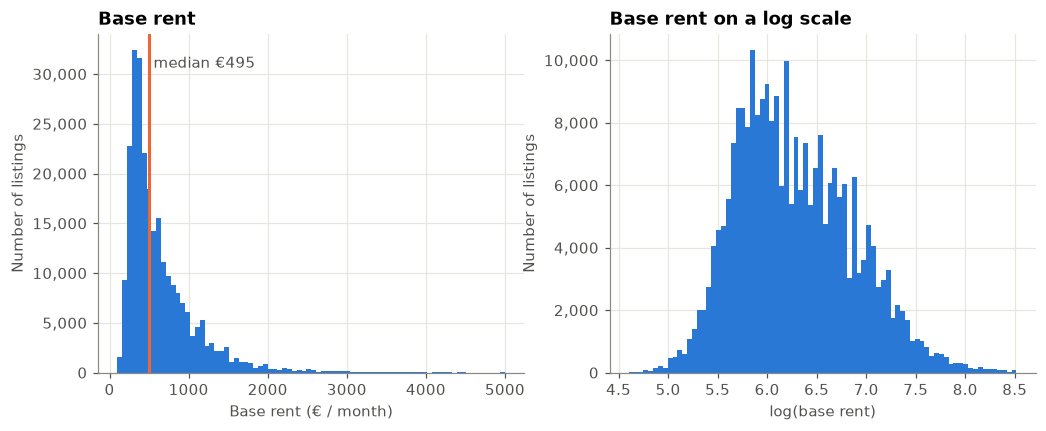

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["baseRent"], bins=80, color=BLUE)
axes[0].axvline(df["baseRent"].median(), color=ORANGE, lw=2)
axes[0].text(df["baseRent"].median() + 60, axes[0].get_ylim()[1] * 0.9,
             f"median €{df['baseRent'].median():.0f}", color=GREY)
axes[0].set(title="Base rent", xlabel="Base rent (€ / month)", ylabel="Number of listings")
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

axes[1].hist(np.log(df["baseRent"]), bins=80, color=BLUE)
axes[1].set(title="Base rent on a log scale", xlabel="log(base rent)", ylabel="Number of listings")
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.savefig("../images/rent_distribution.png")
plt.show()

**Insight:** most apartments rent for **€270–1,200** (10th to 90th percentile), the median is **€495**. The distribution is **right-skewed**: a long tail of expensive flats (about 5% cost more than €1,500).

After taking the **logarithm** (right chart) the shape is much more symmetric, like a bell curve. Many models learn better from such a target, so we'll try predicting `log(rent)` in Phase 4.

### 6.2 Bigger flat → higher rent?

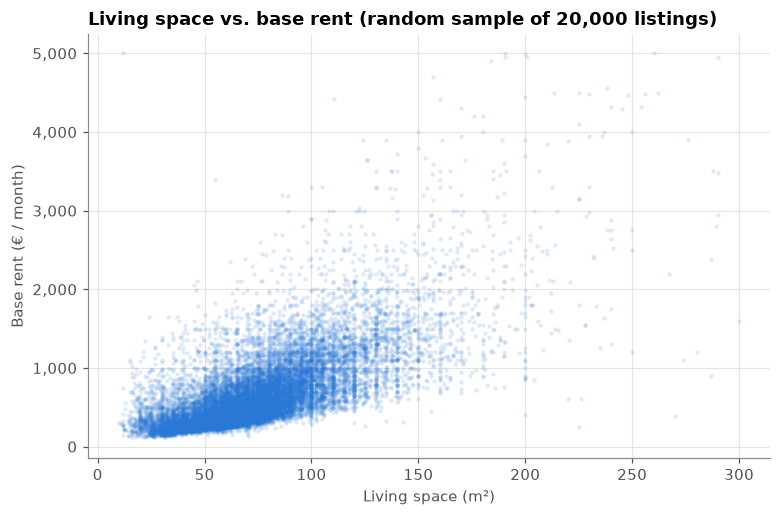

Correlation living space vs. rent: 0.71


In [10]:
sample = df.sample(20_000, random_state=42)   # 20k points are enough to see the pattern
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["livingSpace"], sample["baseRent"], s=8, alpha=0.15, color=BLUE, linewidths=0)
ax.set(title="Living space vs. base rent (random sample of 20,000 listings)",
       xlabel="Living space (m²)", ylabel="Base rent (€ / month)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.savefig("../images/space_vs_rent.png")
plt.show()

print(f"Correlation living space vs. rent: {df['livingSpace'].corr(df['baseRent']):.2f}")

**Insight:** there is a clear, roughly linear relationship – bigger flats cost more (correlation **0.71**; 1 = perfect line, 0 = no relation).
But the cloud **fans out** as size grows: a 100 m² flat can cost €500 or €2,500. Size alone doesn't decide the price – **location** is the obvious candidate for the rest (next chart).

### 6.3 Where is renting expensive?
To compare regions fairly we use the **rent per m²** (otherwise a region with bigger flats would look more expensive), and the **median** so that outliers don't distort it.

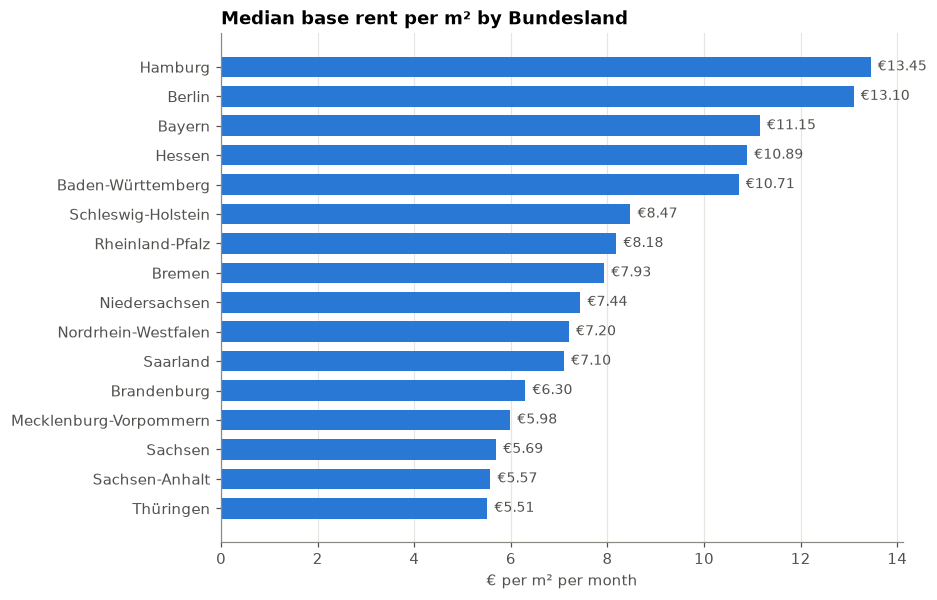

In [11]:
df["rent_per_m2"] = df["baseRent"] / df["livingSpace"]
by_state = df.groupby("regio1")["rent_per_m2"].median().sort_values()
labels = by_state.index.str.replace("_", "-")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, by_state.values, color=BLUE, height=0.7)
for y, value in enumerate(by_state.values):
    ax.text(value + 0.15, y, f"€{value:.2f}", va="center", color=GREY, fontsize=9)
ax.set(title="Median base rent per m² by Bundesland", xlabel="€ per m² per month")
ax.grid(axis="y", visible=False)
plt.savefig("../images/rent_per_m2_by_state.png")
plt.show()

In [12]:
# Cheapest and most expensive cities/districts (regio2) with at least 500 listings
by_city = df.groupby("regio2")["rent_per_m2"].agg(["median", "size"]).query("size >= 500").sort_values("median")
pd.concat([by_city.head(5), by_city.tail(5)]).round(2)

,median,size
regio2,,
Vogtlandkreis,4.60,871
Plauen,4.65,1815
Görlitz_Kreis,4.75,945
Greiz_Kreis,4.89,531
Erzgebirgskreis,4.99,1763
Hamburg,13.45,3659
Frankfurt_am_Main,16.20,4048
München_Kreis,16.26,619
Stuttgart,16.98,1634


**Insight:** location has a **huge** effect. Hamburg (€13.45/m²) and Berlin (€13.10/m²) are **more than twice as expensive** as Thüringen, Sachsen-Anhalt or Sachsen (~€5.5/m²). There's a clear **west/south vs. east** divide.
Within states the differences are even larger: in München a m² costs **€21.43**, in Vogtlandkreis (Sachsen) **€4.60** – almost 5×. So the **city (`regio2`)** should be a very important feature for the model.

## Summary
- 268,850 listings → **257,242 after cleaning** (duplicates, typos and impossible values removed, leakage columns dropped).
- Rent is right-skewed (median €495) → try a **log-transformed target**.
- **Living space** and **location** are the strongest drivers visible so far.
- **Limitation:** NRW and Sachsen are overrepresented; data is from 2018–2020, so absolute prices are lower than today.

Next: `02_modeling.ipynb`